In [78]:
import sys
from pathlib import Path

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

E:\My codes\Medical AI\lung-ai-platform


In [79]:
import numpy as np
np.float = float
np.int = int
import matplotlib.pyplot as plt
import pylidc as pl

from backend.medical.ct_volume import CTVolume

In [80]:
PATIENT_ID = "LIDC-IDRI-0001"

ct = CTVolume(
    r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri\LIDC-IDRI-0001\2000-01-01-30178\3000566-03192"
)

scan = (
    pl.query(pl.Scan)
    .filter(pl.Scan.patient_id == PATIENT_ID)
    .first()
)

nodules = scan.cluster_annotations()

annotation = nodules[0][0]

In [81]:
print(scan)

Scan(id=12,patient_id=LIDC-IDRI-0001)


In [82]:
import pylidc
import numpy

print("pylidc :", pylidc.__version__)
print("numpy  :", numpy.__version__)

pylidc : 0.2.3
numpy  : 2.2.6


In [83]:
print(type(annotation))

print()

print(annotation)

<class 'pylidc.Annotation.Annotation'>

Annotation(id=84,scan_id=12)


In [84]:
[attr for attr in dir(annotation) if not attr.startswith("_")]

['Calcification',
 'InternalStructure',
 'Lobulation',
 'Malignancy',
 'Margin',
 'Sphericity',
 'Spiculation',
 'Subtlety',
 'Texture',
 'bbox',
 'bbox_dims',
 'bbox_matrix',
 'boolean_mask',
 'calcification',
 'centroid',
 'contour_slice_indices',
 'contour_slice_zvals',
 'contours',
 'contours_matrix',
 'diameter',
 'feature_vals',
 'id',
 'internalStructure',
 'lobulation',
 'malignancy',
 'margin',
 'metadata',
 'print_formatted_feature_table',
 'registry',
 'scan',
 'scan_id',
 'sphericity',
 'spiculation',
 'subtlety',
 'surface_area',
 'texture',
 'uniform_cubic_resample',
 'visualize_in_3d',
 'visualize_in_scan',
 'volume']

In [85]:
bbox = annotation.bbox()

print(bbox)

print(type(bbox))

(slice(np.int64(340), np.int64(390), None), slice(np.int64(297), np.int64(338), None), slice(np.int64(86), np.int64(94), None))
<class 'tuple'>


In [86]:
print(annotation.bbox_matrix())

[[340 389]
 [297 337]
 [ 86  93]]


In [87]:
print(annotation.bbox_dims())

[34.453125 28.125    17.5     ]


In [88]:
print(annotation.centroid)

[365.87447257 315.04852321  89.55168776]


In [89]:
print("Diameter :", annotation.diameter)

print("Volume :", annotation.volume)

print("Surface :", annotation.surface_area)

Diameter : 32.20588825480909
Volume : 7869.3695068359375
Surface : 2801.428430573194


In [90]:
mask = annotation.boolean_mask()

print(mask.shape)

print(mask.dtype)

print(mask.min())

print(mask.max())

(50, 41, 8)
bool
False
True


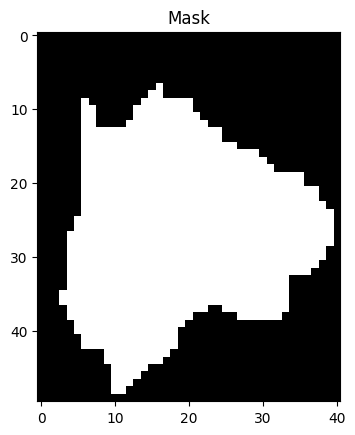

In [91]:
middle = mask.shape[2] // 2

plt.imshow(mask[:, :, middle], cmap="gray")

plt.title("Mask")

plt.show()

In [92]:
print(ct)

print()

print(ct.volume.shape)

CTVolume
-------------------------
Slices          : 133
Rows            : 512
Columns         : 512
Pixel Spacing   : [0.703125, 0.703125]
Slice Thickness : 2.5 mm

(133, 512, 512)


In [93]:
bbox = annotation.bbox()

print("bbox x :", bbox[0])

print("bbox y :", bbox[1])

print("bbox z :", bbox[2])

print()

print("CT shape :", ct.volume.shape)

bbox x : slice(np.int64(340), np.int64(390), None)
bbox y : slice(np.int64(297), np.int64(338), None)
bbox z : slice(np.int64(86), np.int64(94), None)

CT shape : (133, 512, 512)


Loading dicom files ... This may take a moment.


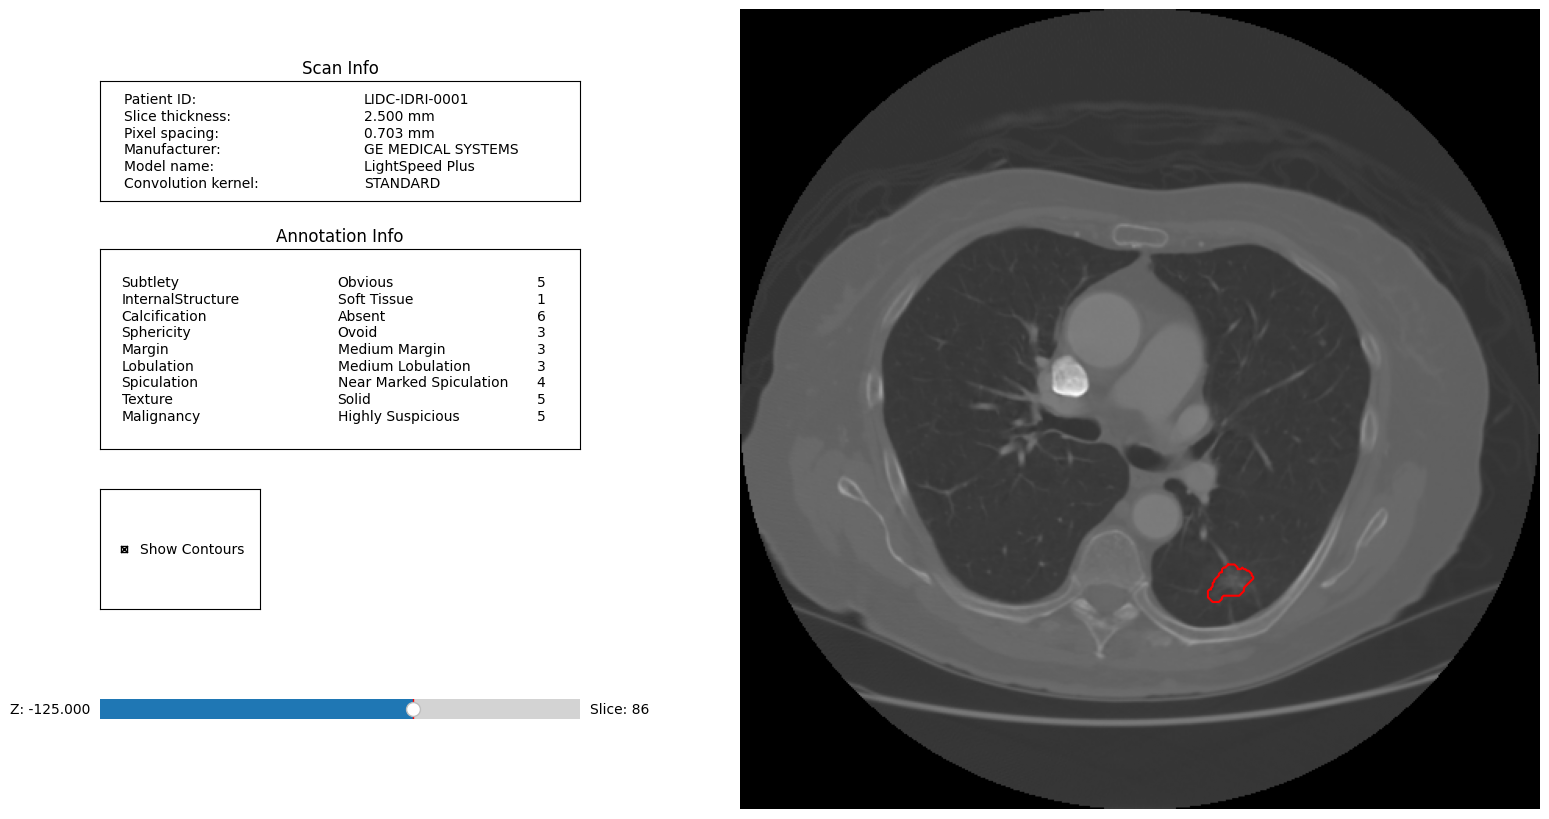

In [94]:
annotation.visualize_in_scan()

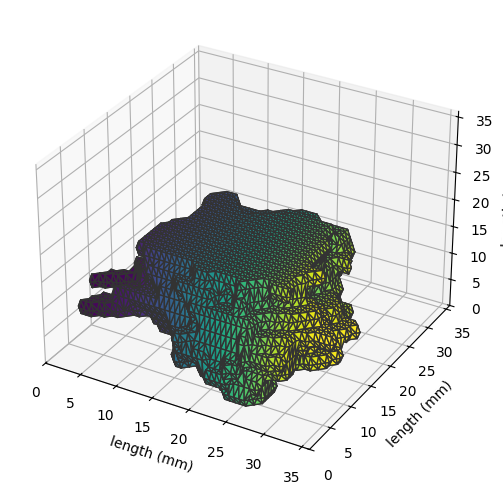

In [95]:
annotation.visualize_in_3d()

In [96]:
resampled = annotation.uniform_cubic_resample()

print(type(resampled))

print(len(resampled))

Loading dicom files ... This may take a moment.
<class 'tuple'>
2


In [97]:
print(annotation.metadata)

MetaData()


In [98]:
print(scan)

print()

print(scan.patient_id)

Scan(id=12,patient_id=LIDC-IDRI-0001)

LIDC-IDRI-0001


In [99]:
[attr for attr in dir(scan) if not attr.startswith("_")]

['annotations',
 'cluster_annotations',
 'contrast_used',
 'get_path_to_dicom_files',
 'id',
 'is_from_initial',
 'load_all_dicom_images',
 'metadata',
 'patient_id',
 'pixel_spacing',
 'registry',
 'series_instance_uid',
 'slice_spacing',
 'slice_thickness',
 'slice_zvals',
 'sorted_dicom_file_names',
 'spacings',
 'study_instance_uid',
 'to_volume',
 'visualize',
 'zvals']

In [100]:
mask = annotation.boolean_mask()
bbox = annotation.bbox()

print("Mask shape:", mask.shape)

print("BBox sizes:")
print("X:", bbox[0].stop - bbox[0].start)
print("Y:", bbox[1].stop - bbox[1].start)
print("Z:", bbox[2].stop - bbox[2].start)

print("Mask dimensions:")
print(mask.shape)

Mask shape: (50, 41, 8)
BBox sizes:
X: 50
Y: 41
Z: 8
Mask dimensions:
(50, 41, 8)


In [101]:
print(len(scan.annotations))

for i, ann in enumerate(scan.annotations[:5]):
    print(i, ann)

4
0 Annotation(id=84,scan_id=12)
1 Annotation(id=85,scan_id=12)
2 Annotation(id=86,scan_id=12)
3 Annotation(id=87,scan_id=12)


In [102]:
annotation = scan.annotations[0]

print("bbox:", annotation.bbox())
print("volume:", annotation.volume)
print("diameter:", annotation.diameter)

bbox: (slice(np.int64(340), np.int64(390), None), slice(np.int64(297), np.int64(338), None), slice(np.int64(86), np.int64(94), None))
volume: 7869.3695068359375
diameter: 32.20588825480909


In [103]:
from backend.medical.lidc_processor import LIDCProcessor


processor = LIDCProcessor(
    r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri"
)


processor.load_patient(
    "LIDC-IDRI-0001"
)


processor.get_annotations()


print(processor)

LIDCProcessor
--------------------
Patient : LIDC-IDRI-0001
Annotations : 4
CT Shape : (133, 512, 512)


In [104]:
samples = processor.create_samples()

print(len(samples))

print(samples[0]["image"].shape)
print(samples[0]["mask"].shape)

4
(0, 41, 8)
(50, 41, 8)


In [105]:
full_mask = processor.create_full_volume_mask()

print(full_mask.shape)
print(full_mask.dtype)
print(full_mask.sum())

(133, 512, 512)
uint8
6547


In [106]:
print("CT shape:", processor.ct.volume.shape)

for ann in processor.annotations[:5]:
    print(ann.bbox())

CT shape: (133, 512, 512)
(slice(np.int64(340), np.int64(390), None), slice(np.int64(297), np.int64(338), None), slice(np.int64(86), np.int64(94), None))
(slice(np.int64(343), np.int64(387), None), slice(np.int64(298), np.int64(341), None), slice(np.int64(87), np.int64(94), None))
(slice(np.int64(343), np.int64(389), None), slice(np.int64(298), np.int64(337), None), slice(np.int64(86), np.int64(94), None))
(slice(np.int64(340), np.int64(392), None), slice(np.int64(298), np.int64(337), None), slice(np.int64(86), np.int64(95), None))


In [107]:
bbox = processor.annotations[0].bbox()

print(bbox[0])
print(bbox[1])
print(bbox[2])

slice(np.int64(340), np.int64(390), None)
slice(np.int64(297), np.int64(338), None)
slice(np.int64(86), np.int64(94), None)


In [108]:
full_mask = processor.create_full_volume_mask()

print(full_mask.shape)
print(full_mask.sum())

(133, 512, 512)
6547


Showing slice: 86


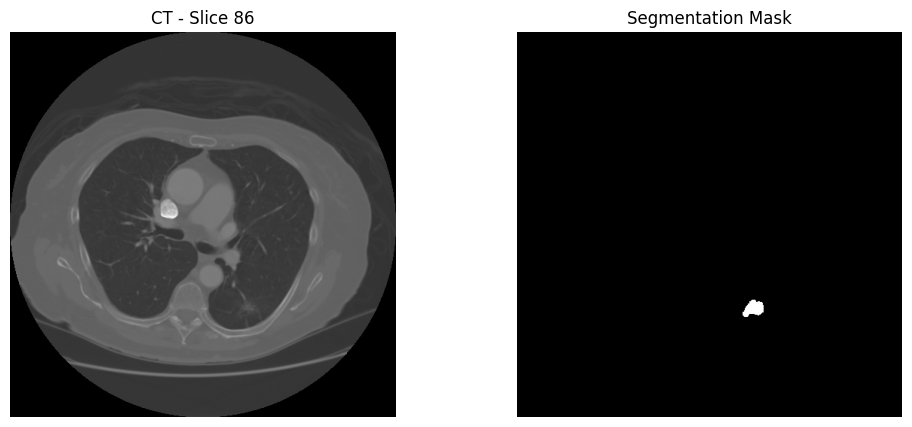

In [109]:
import matplotlib.pyplot as plt

# انتخاب یک slice که احتمالاً داخل نودول است
slice_idx = np.where(full_mask.sum(axis=(1,2)) > 0)[0][0]

print("Showing slice:", slice_idx)


plt.figure(figsize=(12,5))


# CT slice
plt.subplot(1,2,1)

plt.imshow(
    processor.ct.to_hu()[slice_idx],
    cmap="gray"
)

plt.title(f"CT - Slice {slice_idx}")
plt.axis("off")


# Mask slice
plt.subplot(1,2,2)

plt.imshow(
    full_mask[slice_idx],
    cmap="gray"
)

plt.title("Segmentation Mask")
plt.axis("off")


plt.show()

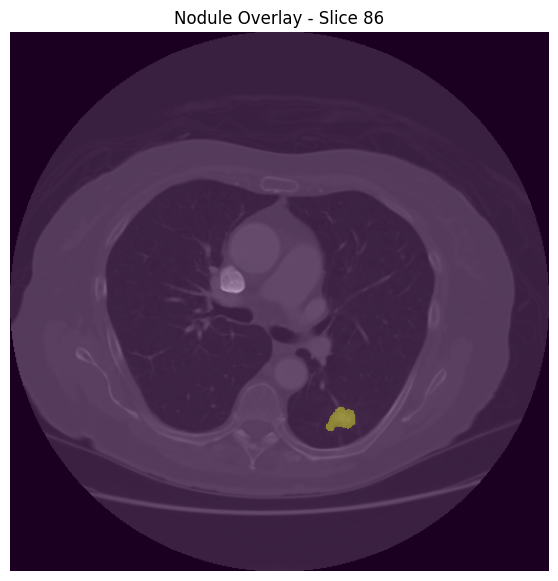

In [110]:
slice_idx = np.where(full_mask.sum(axis=(1,2)) > 0)[0][0]


plt.figure(figsize=(7,7))

plt.imshow(
    processor.ct.to_hu()[slice_idx],
    cmap="gray"
)

plt.imshow(
    full_mask[slice_idx],
    alpha=0.4
)

plt.title(f"Nodule Overlay - Slice {slice_idx}")
plt.axis("off")

plt.show()

In [111]:
processor = LIDCProcessor(
    r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri"
)

processor.load_patient("LIDC-IDRI-0001")

print(processor.ct)

CTVolume
-------------------------
Slices          : 133
Rows            : 512
Columns         : 512
Pixel Spacing   : [0.703125, 0.703125]
Slice Thickness : 2.5 mm


In [112]:
from backend.datasets.lidc_dataset import LIDCDataset

dataset = LIDCDataset(
    r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri"
)

print(len(dataset))

30


In [113]:
sample = dataset[0]

print(sample["patient_id"])

print(sample["image"].shape)

print(sample["mask"].shape)

LIDC-IDRI-0001
torch.Size([1, 133, 512, 512])
torch.Size([1, 133, 512, 512])


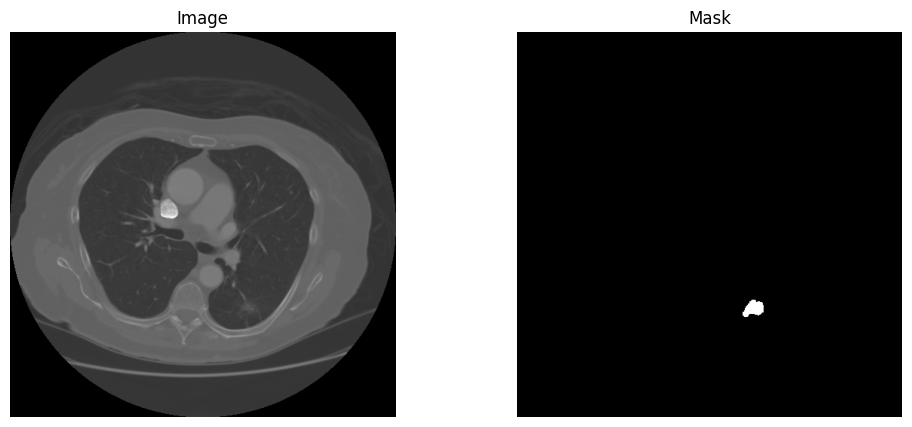

In [114]:
import matplotlib.pyplot as plt

idx = sample["mask"][0].sum(dim=(1,2)).nonzero()[0].item()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(
    sample["image"][0,idx],
    cmap="gray"
)
plt.axis("off")
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(
    sample["mask"][0,idx],
    cmap="gray"
)
plt.axis("off")
plt.title("Mask")

plt.show()

In [115]:
from backend.training.dataloaders import (
    create_train_loader,
    create_val_loader
)

train_loader = create_train_loader(
    dataset_path=r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri"
)

val_loader = create_val_loader(
    dataset_path=r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri"
)

batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["mask"].shape)
print(batch["patient_id"])

torch.Size([1, 1, 238, 512, 512])
torch.Size([1, 1, 238, 512, 512])
['LIDC-IDRI-0017']


In [116]:
scan = (
    pl.query(pl.Scan)
    .filter(pl.Scan.patient_id == "LIDC-IDRI-0002")
    .first()
)

print(scan.get_path_to_dicom_files()[:5])

E:\My


In [117]:
path = scan.get_path_to_dicom_files()

print(type(path))
print(path)

<class 'str'>
E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri\LIDC-IDRI-0002\2000-01-01-98329\3000522-04919


In [118]:
from pathlib import Path

path = Path(scan.get_path_to_dicom_files())

print(path)
print(path.exists())
print(path.is_dir())

E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri\LIDC-IDRI-0002\2000-01-01-98329\3000522-04919
True
True


In [120]:
dataset = LIDCDataset(
    dataset_path=r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri"
)

print(len(dataset))

30


In [121]:
sample = dataset[0]

print(type(sample))
print(sample.keys())

<class 'dict'>
dict_keys(['image', 'mask', 'patient_id'])


In [122]:
print(sample["patient_id"])

print(sample["image"].shape)
print(sample["mask"].shape)

print(sample["image"].dtype)
print(sample["mask"].dtype)

LIDC-IDRI-0001
torch.Size([1, 133, 512, 512])
torch.Size([1, 133, 512, 512])
torch.float32
torch.float32


In [123]:
print(sample["image"].min())
print(sample["image"].max())

print(sample["mask"].min())
print(sample["mask"].max())

tensor(-2048.)
tensor(3071.)
tensor(0.)
tensor(1.)


In [124]:
train_loader = create_train_loader(
    dataset_path=r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri",
    batch_size=1
)

batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["mask"].shape)
print(batch["patient_id"])

torch.Size([1, 1, 209, 512, 512])
torch.Size([1, 1, 209, 512, 512])
['LIDC-IDRI-0015']
